In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from main import main 
data=main()

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30375 entries, I Don't Care (with Justin Bieber) - Loud Luxury Remix to Typhoon - Original Mix
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   track_artist              30375 non-null  object        
 1   track_popularity          30375 non-null  int64         
 2   track_album_name          30375 non-null  object        
 3   track_album_release_date  30375 non-null  datetime64[ns]
 4   playlist_genre            30375 non-null  object        
 5   danceability              30375 non-null  float64       
 6   energy                    30375 non-null  float64       
 7   key                       30375 non-null  int64         
 8   loudness                  30375 non-null  float64       
 9   mode                      30375 non-null  int64         
 10  speechiness               30375 non-null  float64       
 11  acousticness    

In [24]:
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

In [25]:
analysis_data = data.dropna(subset=features + ['playlist_genre']).copy()

In [26]:
scaler=StandardScaler()
X=data[features]
X_scaled=scaler.fit_transform(X)

In [27]:
k_means=KMeans(n_clusters=6, random_state=7, n_init=16)

In [28]:
analysis_data['cluster'] = k_means.fit_predict(X_scaled)

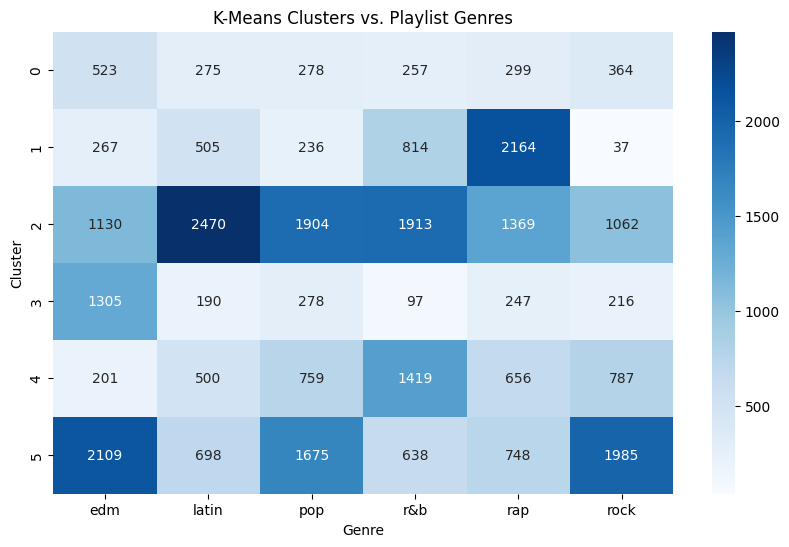

In [29]:
plt.figure(figsize=(10, 6))
crosstab = pd.crosstab(analysis_data['cluster'], analysis_data['playlist_genre'])
sns.heatmap(crosstab, cmap='Blues', annot=True, fmt='d')
plt.title('K-Means Clusters vs. Playlist Genres')
plt.ylabel('Cluster')
plt.xlabel('Genre')
plt.show()